In [2]:
import pandas as pd
import numpy as np
import sklearn as sk

In [42]:
dataset = pd.read_csv("/dataset_heart.csv")

In [43]:
df = pd.DataFrame(dataset)

In [44]:
df.head(5)

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [45]:
# Data Pre-Processing

Needed feautures that can be extracted from medical reports for heart disease prediction are :
1. age
2. sex
3. chest pain type
4. blood pressure
5. cholestrol
6. resting blood sugar
7. fasting blood sugar
8. ECG result

Feautures that are least expected to get from medical reports are :

9. maximum heart rate achieved
10. exercise induced angina
11.	oldpeak (ST depression)
12. ST segment slope

In [46]:
# drop unnecessary features from the dataframe
df = df.drop(columns = ["exercise induced angina","max heart rate","oldpeak","ST segment"])


In [47]:
df.head()

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,3,3,2
1,67,0,3,115,564,0,2,0,7,1
2,57,1,2,124,261,0,0,0,7,2
3,64,1,4,128,263,0,0,1,7,1
4,74,0,2,120,269,0,2,1,3,1


In [48]:
df = df.drop(columns=["major vessels", "thal"])

In [49]:
df.head(5)

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,heart disease
0,70,1,4,130,322,0,2,2
1,67,0,3,115,564,0,2,1
2,57,1,2,124,261,0,0,2
3,64,1,4,128,263,0,0,1
4,74,0,2,120,269,0,2,1


In [50]:
# Renaming the feautures
df = df.rename(columns={
    "age": "Age",
    "sex": "Gender",
    "chest pain type": "Chest Pain",
    "resting blood pressure": "Resting BP",
    "serum cholestoral": "Total Cholesterol",
    "fasting blood sugar": "Fasting Blood Sugar",
    "resting electrocardiographic results": "ECG Findings",
    "heart disease": "target"
})


sex - 0 (Female) 1 (Male)

chest pain -

    0	Typical Angina	Chest pain on exertion, relieved by rest
    1 Atypical Angina	Chest discomfort, not classic angina
    2	Non-anginal Pain	Chest pain not related to the heart
    3	Asymptomatic	No chest pain

fbs_mapping = {
    0: "<=120 mg/dL",
    1: ">120 mg/dL"
}

restecg_mapping = {
    0: "Normal",
    1: "ST-T wave abnormality",
    2: "Left ventricular hypertrophy"
}


In [51]:
df.head(5)

,Age,sex,Chest Pain,Resting BP,Total Cholesterol,Fasting Blood Sugar,ECG Findings,target
0,70,1,4,130,322,0,2,2
1,67,0,3,115,564,0,2,1
2,57,1,2,124,261,0,0,2
3,64,1,4,128,263,0,0,1
4,74,0,2,120,269,0,2,1


The model predicts the likelihood of heart disease using non-invasive parameters commonly available in Indian medical reports, making it suitable for early screening and decision support

In [52]:
# fixing column values
df["target"] = df["target"].map({1: 0, 2: 1})


In [53]:
df["Chest Pain"] = df["Chest Pain"] - 1


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Age                  270 non-null    int64
 1   sex                  270 non-null    int64
 2   Chest Pain           270 non-null    int64
 3   Resting BP           270 non-null    int64
 4   Total Cholesterol    270 non-null    int64
 5   Fasting Blood Sugar  270 non-null    int64
 6   ECG Findings         270 non-null    int64
 7   target               270 non-null    int64
dtypes: int64(8)
memory usage: 17.0 KB


In [55]:
df.describe()

,Age,sex,Chest Pain,Resting BP,Total Cholesterol,Fasting Blood Sugar,ECG Findings,target
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,2.174074,131.344444,249.659259,0.148148,1.022222,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,0.497827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,213.000000,0.000000,0.000000,0.000000
50%,55.000000,1.000000,2.000000,130.000000,245.000000,0.000000,2.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,280.000000,0.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,1.000000


In [56]:
len(dataset)

270

In [57]:
df.columns = (
    df.columns
    .str.strip()        # remove leading/trailing spaces
    .str.lower()        # make lowercase
    .str.replace(" ", "_")
)


Validating ranges of data

In [58]:
print(df.columns.tolist())


['age', 'sex', 'chest_pain', 'resting_bp', 'total_cholesterol', 'fasting_blood_sugar', 'ecg_findings', 'target']


In [59]:
assert df["age"].between(20, 100).all()
assert df["resting_bp"].between(80, 220).all()
assert df["total_cholesterol"].between(100, 700).all()
assert df["sex"].isin([0, 1]).all()
assert df["fasting_blood_sugar"].isin([0, 1]).all()
assert df["ecg_findings"].isin([0, 1, 2]).all()


In [60]:
# Handling missing values
df.isnull().sum()

,0
age,0
sex,0
chest_pain,0
resting_bp,0
total_cholesterol,0
fasting_blood_sugar,0
ecg_findings,0
target,0


In [61]:
df.duplicated().sum()

np.int64(0)

EDA (Exploratory Data Analysis)

In [62]:
df.shape

(270, 8)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  270 non-null    int64
 1   sex                  270 non-null    int64
 2   chest_pain           270 non-null    int64
 3   resting_bp           270 non-null    int64
 4   total_cholesterol    270 non-null    int64
 5   fasting_blood_sugar  270 non-null    int64
 6   ecg_findings         270 non-null    int64
 7   target               270 non-null    int64
dtypes: int64(8)
memory usage: 17.0 KB


In [64]:
df.describe()

,age,sex,chest_pain,resting_bp,total_cholesterol,fasting_blood_sugar,ecg_findings,target
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,2.174074,131.344444,249.659259,0.148148,1.022222,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,0.497827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,213.000000,0.000000,0.000000,0.000000
50%,55.000000,1.000000,2.000000,130.000000,245.000000,0.000000,2.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,280.000000,0.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,1.000000


Checking for target variable distibution

In [65]:
df["target"].value_counts()

,count
target,
0,150
1,120


NUmerical feauture distribution

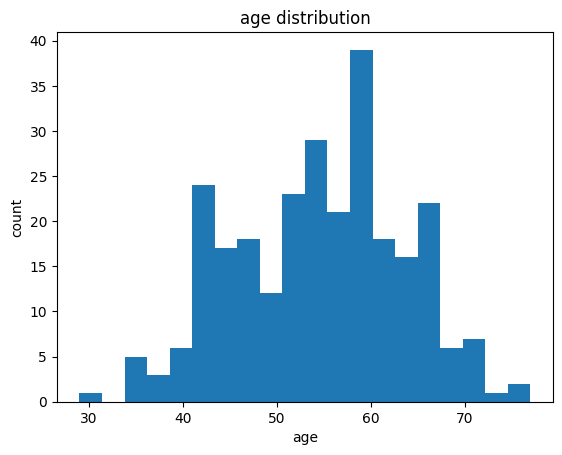

In [66]:
import matplotlib.pyplot as plt

plt.hist(df["age"] , bins = 20)
plt.xlabel("age")
plt.ylabel("count")
plt.title("age distribution")
plt.show()

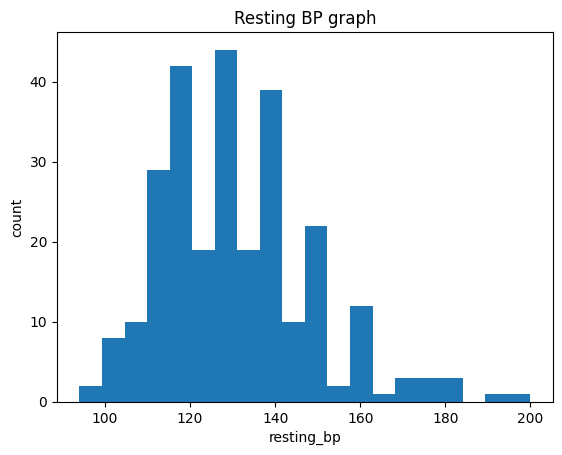

In [67]:
plt.hist(df["resting_bp"] , bins = 20)
plt.xlabel("resting_bp")
plt.ylabel("count")
plt.title("Resting BP graph")
plt.show()

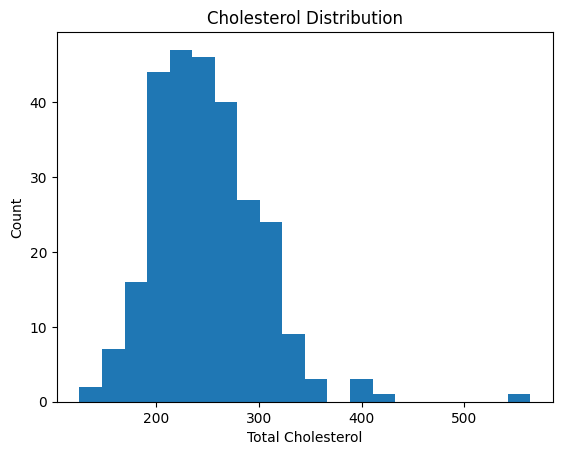

In [68]:
plt.hist(df["total_cholesterol"], bins=20)
plt.xlabel("Total Cholesterol")
plt.ylabel("Count")
plt.title("Cholesterol Distribution")
plt.show()


We can see that the data is symmetric and there is no outlier since most of the values are between 110 - 150

CATEGORICAL FEAUTURE ANALYSIS

In [71]:
import pandas as pd # as we can see that there are 67 femaleand 83 male

pd.crosstab(df["sex"], df["target"])


target,0,1
sex,,
0,67,20
1,83,100


Male patients exhibit a higher prevalence of heart disease compared to female patients, consistent with known epidemiological trends

In [70]:
pd.crosstab(df["chest_pain"], df["target"])


target,0,1
chest_pain,,
0,15,5
1,35,7
2,62,17
3,38,91


Asymptomatic chest pain shows a strong association with heart disease, whereas typical and atypical angina are more frequently observed in non-diseased individuals.

In [72]:
pd.crosstab(df["ecg_findings"] , df["target"])

target,0,1
ecg_findings,,
0,85,46
1,1,1
2,64,73


Left ventricular hypertrophy observed in ECG findings is associated with a higher incidence of heart disease.

Final - Exploratory data analysis revealed strong associations between heart disease and clinical features such as chest pain type, sex, and ECG findings. Asymptomatic chest pain and left ventricular hypertrophy were particularly associated with higher disease prevalence. These observations align with established clinical knowledge and validate the relevance of the selected features.

BINARY FEAUTURE ANALYSIS

In [75]:
pd.crosstab(df["fasting_blood_sugar"], df["target"])


target,0,1
fasting_blood_sugar,,
0,127,103
1,23,17


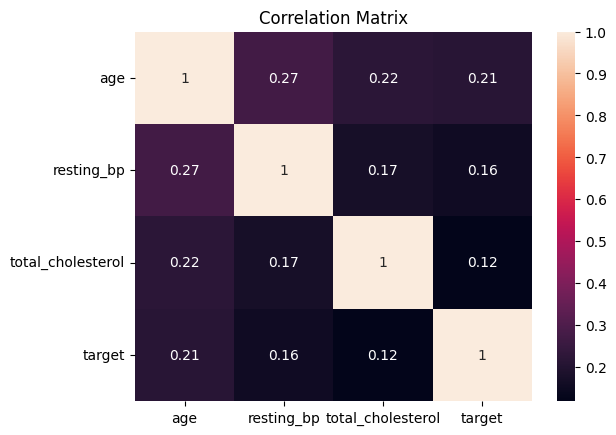

In [76]:
# CORRELATION ANALYSIS
import seaborn as sns

num_df = df[["age", "resting_bp", "total_cholesterol", "target"]]

sns.heatmap(num_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


Fasting blood sugar showed a relatively weak association with heart disease when considered independently, suggesting that its predictive value is more meaningful when combined with other clinical features.

In [80]:
y = df["target"]

In [83]:
X = df.drop(columns = ["target"])

In [84]:
X

,age,sex,chest_pain,resting_bp,total_cholesterol,fasting_blood_sugar,ecg_findings
0,70,1,3,130,322,0,2
1,67,0,2,115,564,0,2
2,57,1,1,124,261,0,0
3,64,1,3,128,263,0,0
4,74,0,1,120,269,0,2
...,...,...,...,...,...,...,...
265,52,1,2,172,199,1,0
266,44,1,1,120,263,0,0
267,56,0,1,140,294,0,2
268,57,1,3,140,192,0,0


In [88]:
num_features = ["age", "resting_bp", "total_cholesterol"]
bin_features = ["sex", "fasting_blood_sugar"]
cat_features = ["chest_pain", "ecg_findings"]


In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features),
        ("bin", "passthrough", bin_features)
    ]
)


In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [91]:
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

print(X_train_p.shape, X_test_p.shape)


(216, 10) (54, 10)


Model Building

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline(steps=[
    ("classifier", LogisticRegression(max_iter=1000))
])


In [93]:
logreg_model.fit(X_train, y_train)


Pipeline(steps=[('classifier', LogisticRegression(max_iter=1000))])

In [94]:
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]


In [95]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[18 12]
 [ 5 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.60      0.68        30
           1       0.61      0.79      0.69        24

    accuracy                           0.69        54
   macro avg       0.70      0.70      0.69        54
weighted avg       0.71      0.69      0.68        54

ROC-AUC Score: 0.8041666666666667


RANDOM FOREST

In [96]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'resting_bp',
                                                   'total_cholesterol']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['chest_pain',
                                                   'ecg_findings']),
                                                 ('bin', 'passthrough',
                                                  ['sex',
                                                   'fasting_blood_sugar'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=6, n_estimators=200,
                                        random_state=42))])

In [97]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))


Confusion Matrix:
 [[21  9]
 [ 3 21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.70      0.78        30
           1       0.70      0.88      0.78        24

    accuracy                           0.78        54
   macro avg       0.79      0.79      0.78        54
weighted avg       0.80      0.78      0.78        54

ROC-AUC Score: 0.8319444444444445


Among the evaluated models, Random Forest outperformed Logistic Regression, achieving an accuracy of 78% and a recall of 88% for heart disease cases. This indicates its effectiveness in capturing non-linear relationships among clinical features, making it more suitable for early risk prediction in this study.

Creating .pkl of both

In [98]:
import joblib

joblib.dump(logreg_model, "logistic_regression_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")


['random_forest_model.pkl']

In [99]:
import os

print(os.path.exists("logistic_regression_model.pkl"))
print(os.path.exists("random_forest_model.pkl"))


True
True


Veryfying files are created are not

In [100]:
logreg_loaded = joblib.load("logistic_regression_model.pkl")
rf_loaded = joblib.load("random_forest_model.pkl")


In [101]:
import pandas as pd

test_input = pd.DataFrame([{
    "age": 60,
    "sex": 1,
    "chest_pain": 3,
    "resting_bp": 145,
    "total_cholesterol": 260,
    "fasting_blood_sugar": 1,
    "ecg_findings": 2
}])

print(rf_loaded.predict(test_input))
print(rf_loaded.predict_proba(test_input))


[1]
[[0.09817929 0.90182071]]


In [102]:
print(logreg_loaded.predict(test_input))
print(logreg_loaded.predict_proba(test_input))

[1]
[[0.14386438 0.85613562]]
